In [1]:
import anndata
import gc
import SimpleITK as sitk
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
download_base = Path('/data/scRNA/ABCA/AIBS/AWS/')
abc_cache = AbcProjectCache.from_cache_dir(download_base)

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/abc_atlas_access/abc_atlas_cache/cloud_cache.py:630: OutdatedManifestWarning: You are loading releases/20241130/manifest.json. A more up to date version of the dataset -- releases/20250131/manifest.json -- exists online. To see the changes between the two versions of the dataset, run
type.compare_manifests('releases/20241130/manifest.json', 'releases/20250131/manifest.json')
To load another version of the dataset, run
type.load_manifest('releases/20250131/manifest.json')
  warnings.warn(msg, OutdatedManifestWarning)


In [3]:
cell = abc_cache.get_metadata_dataframe(
    directory='MERFISH-C57BL6J-638850',
    file_name='cell_metadata_with_cluster_annotation')
cell.rename(columns={'x': 'x_section',
                     'y': 'y_section',
                     'z': 'z_section'},
            inplace=True)
cell.set_index('cell_label', inplace=True)
cell.head(5)

,brain_section_label,cluster_alias,average_correlation_score,feature_matrix_label,donor_label,donor_genotype,donor_sex,x_section,y_section,z_section,neurotransmitter,class,subclass,supertype,cluster,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color
cell_label,,,,,,,,,,,,,,,,,,,,
1019171907102340387-1,C57BL6J-638850.37,1408,0.596276,C57BL6J-638850,C57BL6J-638850,wt/wt,M,7.226245,4.148963,6.6,NaN,04 DG-IMN Glut,038 DG-PIR Ex IMN,0141 DG-PIR Ex IMN_2,0515 DG-PIR Ex IMN_2,#666666,#16f2f2,#3D53CC,#CC7A3D,#73FFBF
1104095349101460194-1,C57BL6J-638850.26,4218,0.641180,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.064889,7.309543,4.2,Glut,23 P Glut,235 PG-TRN-LRN Fat2 Glut,0953 PG-TRN-LRN Fat2 Glut_1,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63
1017092617101450577,C57BL6J-638850.25,4218,0.763531,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.792921,8.189973,4.0,Glut,23 P Glut,235 PG-TRN-LRN Fat2 Glut,0953 PG-TRN-LRN Fat2 Glut_1,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63
1018093344101130233,C57BL6J-638850.13,4218,0.558073,C57BL6J-638850,C57BL6J-638850,wt/wt,M,3.195950,5.868655,2.4,Glut,23 P Glut,235 PG-TRN-LRN Fat2 Glut,0953 PG-TRN-LRN Fat2 Glut_1,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63
1019171912201610094,C57BL6J-638850.27,4218,0.591009,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.635732,7.995842,4.4,Glut,23 P Glut,235 PG-TRN-LRN Fat2 Glut,0953 PG-TRN-LRN Fat2 Glut_1,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63


In [4]:
reconstructed_coords = abc_cache.get_metadata_dataframe(
    directory='MERFISH-C57BL6J-638850-CCF',
    file_name='reconstructed_coordinates',
    dtype={"cell_label": str}
)
reconstructed_coords.rename(columns={'x': 'x_reconstructed',
                                     'y': 'y_reconstructed',
                                     'z': 'z_reconstructed'},
                            inplace=True)
reconstructed_coords.set_index('cell_label', inplace=True)
reconstructed_coords.head(5)

,x_reconstructed,y_reconstructed,z_reconstructed,parcellation_index
cell_label,,,,
1019171911101460569,7.143894,7.890964,0.8,945
1019171911101550321,4.188673,7.962972,0.8,945
1019171911100841066,6.859447,5.908534,0.8,893
1019171911101400425,3.952014,7.564086,0.8,842
1019171911101380264,2.803546,7.221688,0.8,0


In [5]:
cell_joined = cell.join(reconstructed_coords, how='inner')
cell_joined.head(5)

,brain_section_label,cluster_alias,average_correlation_score,feature_matrix_label,donor_label,donor_genotype,donor_sex,x_section,y_section,z_section,...,cluster,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color,x_reconstructed,y_reconstructed,z_reconstructed,parcellation_index
cell_label,,,,,,,,,,,,,,,,,,,,,
1019171907102340387-1,C57BL6J-638850.37,1408,0.596276,C57BL6J-638850,C57BL6J-638850,wt/wt,M,7.226245,4.148963,6.6,...,0515 DG-PIR Ex IMN_2,#666666,#16f2f2,#3D53CC,#CC7A3D,#73FFBF,7.255606,4.007680,6.6,1160
1104095349101460194-1,C57BL6J-638850.26,4218,0.641180,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.064889,7.309543,4.2,...,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63,5.036436,7.264429,4.2,564
1017092617101450577,C57BL6J-638850.25,4218,0.763531,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.792921,8.189973,4.0,...,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63,5.784270,8.007646,4.0,761
1018093344101130233,C57BL6J-638850.13,4218,0.558073,C57BL6J-638850,C57BL6J-638850,wt/wt,M,3.195950,5.868655,2.4,...,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63,3.161528,5.719814,2.4,718
1019171912201610094,C57BL6J-638850.27,4218,0.591009,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.635732,7.995842,4.4,...,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63,5.618763,7.847877,4.4,761


In [6]:
ccf_coords = abc_cache.get_metadata_dataframe(
    directory='MERFISH-C57BL6J-638850-CCF',
    file_name='ccf_coordinates',
    dtype={"cell_label": str}
)
ccf_coords.rename(columns={'x': 'x_ccf',
                           'y': 'y_ccf',
                           'z': 'z_ccf'},
                  inplace=True)
ccf_coords.drop(['parcellation_index'], axis=1, inplace=True)
ccf_coords.set_index('cell_label', inplace=True)
ccf_coords.head(5)

,x_ccf,y_ccf,z_ccf
cell_label,,,
1019171911101460569,12.282330,6.987808,7.385773
1019171911101550321,12.192214,7.002155,4.366855
1019171911100841066,12.500341,4.750392,7.074634
1019171911101400425,12.231647,6.544816,4.128568
1019171911101380264,12.238502,6.135836,2.948194


In [7]:
cell_joined = cell_joined.join(ccf_coords, how='inner')
cell_joined.head(5)

,brain_section_label,cluster_alias,average_correlation_score,feature_matrix_label,donor_label,donor_genotype,donor_sex,x_section,y_section,z_section,...,subclass_color,supertype_color,cluster_color,x_reconstructed,y_reconstructed,z_reconstructed,parcellation_index,x_ccf,y_ccf,z_ccf
cell_label,,,,,,,,,,,,,,,,,,,,,
1019171907102340387-1,C57BL6J-638850.37,1408,0.596276,C57BL6J-638850,C57BL6J-638850,wt/wt,M,7.226245,4.148963,6.6,...,#3D53CC,#CC7A3D,#73FFBF,7.255606,4.007680,6.6,1160,7.495417,2.445872,7.455066
1104095349101460194-1,C57BL6J-638850.26,4218,0.641180,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.064889,7.309543,4.2,...,#9B7ACC,#990041,#663D63,5.036436,7.264429,4.2,564,9.227966,6.133693,5.225024
1017092617101450577,C57BL6J-638850.25,4218,0.763531,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.792921,8.189973,4.0,...,#9B7ACC,#990041,#663D63,5.784270,8.007646,4.0,761,9.344912,6.989939,6.002664
1018093344101130233,C57BL6J-638850.13,4218,0.558073,C57BL6J-638850,C57BL6J-638850,wt/wt,M,3.195950,5.868655,2.4,...,#9B7ACC,#990041,#663D63,3.161528,5.719814,2.4,718,10.977068,4.398568,3.305223
1019171912201610094,C57BL6J-638850.27,4218,0.591009,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.635732,7.995842,4.4,...,#9B7ACC,#990041,#663D63,5.618763,7.847877,4.4,761,8.997138,6.798329,5.827197


In [8]:
def plot_section(xx=None, yy=None, cc=None, val=None, pcmap=None, 
                 overlay=None, extent=None, bcmap=plt.cm.Greys_r, alpha=1.0,
                 fig_width = 6, fig_height = 6):
    
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    if xx is not None and yy is not None and pcmap is not None:
        plt.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=pcmap)
    elif xx is not None and yy is not None and cc is not None:
        plt.scatter(xx, yy, s=0.5, color=cc, marker='.', zorder=1)   
        
    if overlay is not None and extent is not None and bcmap is not None:
        plt.imshow(overlay, cmap=bcmap, extent=extent, alpha=alpha, zorder=2)
        
    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    
    return fig, ax

In [9]:
brain_section = 'C57BL6J-638850.40'
pred = (cell_joined['brain_section_label'] == brain_section)
section = cell_joined[pred]
print(len(section))

104572


In [12]:
print("z_section values:", np.unique(section['z_section']))
print("z_reconstructed values:", np.unique(section['z_reconstructed']))
print("x_ccf values:", np.unique(section['x_ccf']))

z_section values: [7.2]
z_reconstructed values: [7.2]
x_ccf values: [6.32598314 6.32656693 6.3266852  ... 7.16574148 7.16579943 7.16598123]


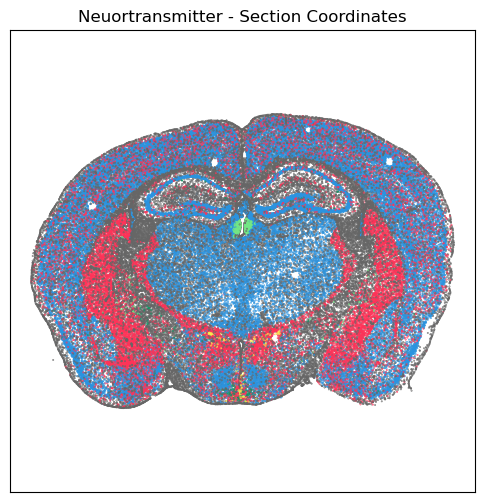

In [13]:
fig, ax = plot_section(xx=section['x_section'],
                       yy=section['y_section'], 
                       cc=section['neurotransmitter_color'])
res = ax.set_title("Neuortransmitter - Section Coordinates")
plt.show()

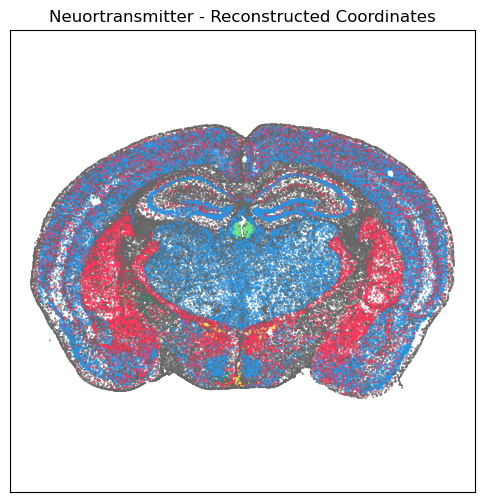

In [14]:
fig, ax = plot_section(xx=section['x_reconstructed'],
                       yy=section['y_reconstructed'], 
                       cc=section['neurotransmitter_color'])
res = ax.set_title("Neuortransmitter - Reconstructed Coordinates")
plt.show()

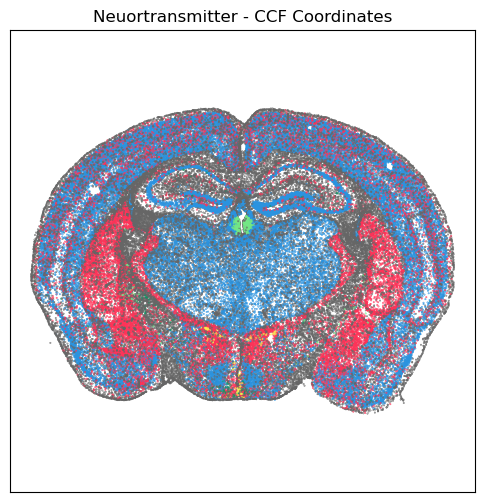

In [15]:
fig, ax = plot_section(xx=section['z_ccf'],
                       yy=section['y_ccf'], 
                       cc=section['neurotransmitter_color'])
res = ax.set_title("Neuortransmitter - CCF Coordinates")
plt.show()

In [8]:
parcellation_annotation = abc_cache.get_metadata_dataframe(directory='Allen-CCF-2020',
                                                           file_name='parcellation_to_parcellation_term_membership_acronym')
parcellation_annotation.set_index('parcellation_index', inplace=True)
parcellation_annotation.columns = ['parcellation_%s'% x for x in  parcellation_annotation.columns]
parcellation_annotation.head(5)

,parcellation_organ,parcellation_category,parcellation_division,parcellation_structure,parcellation_substructure
parcellation_index,,,,,
0,unassigned,unassigned,unassigned,unassigned,unassigned
1,brain,grey,HY,TMv,TMv
2,brain,grey,Isocortex,SSp-m,SSp-m6b
5,brain,fiber tracts,lfbs,cst,int
6,brain,grey,P,PSV,PSV


In [9]:
parcellation_color = abc_cache.get_metadata_dataframe(directory='Allen-CCF-2020',
                                                      file_name='parcellation_to_parcellation_term_membership_color')
parcellation_color.set_index('parcellation_index', inplace=True)
parcellation_color.columns = ['parcellation_%s'% x for x in  parcellation_color.columns]
parcellation_color.head(5)

,parcellation_organ_color,parcellation_category_color,parcellation_division_color,parcellation_structure_color,parcellation_substructure_color
parcellation_index,,,,,
0,#000000,#000000,#000000,#000000,#000000
1,#FFFFFF,#BFDAE3,#E64438,#FF4C3E,#FF4C3E
2,#FFFFFF,#BFDAE3,#70FF71,#188064,#188064
5,#FFFFFF,#CCCCCC,#CCCCCC,#CCCCCC,#CCCCCC
6,#FFFFFF,#BFDAE3,#FF9B88,#FFAE6F,#FFAE6F


In [10]:
cell_joined = cell_joined.join(parcellation_annotation, on='parcellation_index')
cell_joined = cell_joined.join(parcellation_color, on='parcellation_index')
cell_joined.head(5)

,brain_section_label,cluster_alias,average_correlation_score,feature_matrix_label,donor_label,donor_genotype,donor_sex,x_section,y_section,z_section,...,parcellation_organ,parcellation_category,parcellation_division,parcellation_structure,parcellation_substructure,parcellation_organ_color,parcellation_category_color,parcellation_division_color,parcellation_structure_color,parcellation_substructure_color
cell_label,,,,,,,,,,,,,,,,,,,,,
1019171907102340387-1,C57BL6J-638850.37,1408,0.596276,C57BL6J-638850,C57BL6J-638850,wt/wt,M,7.226245,4.148963,6.6,...,brain,grey,HPF,DG,DG-po,#FFFFFF,#BFDAE3,#7ED04B,#7ED04B,#7ED04B
1104095349101460194-1,C57BL6J-638850.26,4218,0.641180,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.064889,7.309543,4.2,...,brain,grey,P,TRN,TRN,#FFFFFF,#BFDAE3,#FF9B88,#FFBA86,#FFBA86
1017092617101450577,C57BL6J-638850.25,4218,0.763531,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.792921,8.189973,4.0,...,brain,grey,P,P-unassigned,P-unassigned,#FFFFFF,#BFDAE3,#FF9B88,#FF9B88,#FF9B88
1018093344101130233,C57BL6J-638850.13,4218,0.558073,C57BL6J-638850,C57BL6J-638850,wt/wt,M,3.195950,5.868655,2.4,...,brain,fiber tracts,cbf,arb,arb,#FFFFFF,#CCCCCC,#CCCCCC,#CCCCCC,#CCCCCC
1019171912201610094,C57BL6J-638850.27,4218,0.591009,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.635732,7.995842,4.4,...,brain,grey,P,P-unassigned,P-unassigned,#FFFFFF,#BFDAE3,#FF9B88,#FF9B88,#FF9B88


In [20]:
pred = (cell_joined['brain_section_label'] == brain_section)
section = cell_joined[pred]
print(len(section))

104572


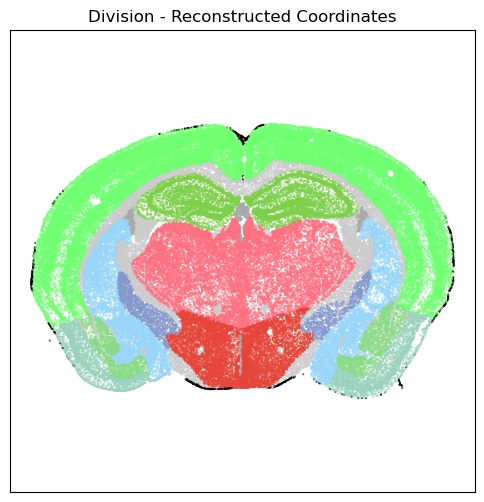

In [21]:
fig, ax = plot_section(xx=section['x_reconstructed'],
                       yy=section['y_reconstructed'], 
                       cc=section['parcellation_division_color'])
res = ax.set_title("Division - Reconstructed Coordinates")
plt.show()

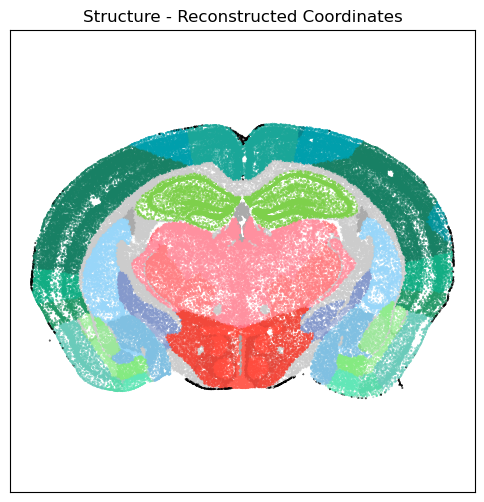

In [22]:
fig, ax = plot_section(xx=section['x_reconstructed'],
                       yy=section['y_reconstructed'], 
                       cc=section['parcellation_structure_color'])
res = ax.set_title("Structure - Reconstructed Coordinates")
plt.show()

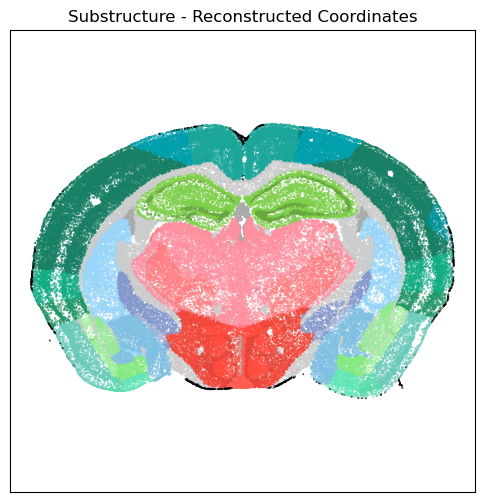

In [23]:
fig, ax = plot_section(xx=section['x_reconstructed'],
                       yy=section['y_reconstructed'], 
                       cc=section['parcellation_substructure_color'])
res = ax.set_title("Substructure - Reconstructed Coordinates")
plt.show()

In [24]:
def parcellation_cell_count (df,level) :
    cell_count = df.groupby(level)[['cluster_alias']].count()
    cell_count.columns = ['number_of_cells']
    cell_count.sort_values('number_of_cells', ascending=False, inplace=True)
    return cell_count

In [25]:
cell_count = parcellation_cell_count(cell_joined, 'parcellation_division')
cell_count.head(10)

,number_of_cells
parcellation_division,
Isocortex,935742
STR,401346
CB,383127
HPF,304642
MB,281852
OLF,274354
MY,147562
P,136569
TH,133805


In [26]:
cell_count = parcellation_cell_count(section, 'parcellation_structure')
cell_count.head(10)

,number_of_cells
parcellation_structure,
SSp-bfd,8865
SSs,7210
CP,4715
DG,4491
VISa,4462
CA1,3705
PIR,3119
cst,3000
cc,2858


In [27]:
pred = (cell_joined['subclass'] == '145 MH Tac2 Glut')
filtered = cell_joined[pred]
print("number of cells:", len(filtered))
cell_count = parcellation_cell_count(filtered, 'parcellation_structure')
cell_count.head(10)

number of cells: 4696


,number_of_cells
parcellation_structure,
MH,4404
V3-unassigned,132
mfsbshy,73
brain-unassigned,46
chpl,21
LH,12
DG,3
TH-unassigned,2
LP,1


In [28]:
pred = (cell_joined['subclass'] == '146 LH Pou4f1 Sox1 Glut')
filtered = cell_joined[pred]
print("number of cells:", len(filtered))
cell_count = parcellation_cell_count(filtered, 'parcellation_structure')
cell_count.head(10)

number of cells: 1067


,number_of_cells
parcellation_structure,
LH,851
mfsbshy,109
MH,59
PAG,10
TH-unassigned,10
brain-unassigned,7
PF,6
DG,5
MD,4


In [29]:
pred = (cell_joined['subclass'] == '147 AD Serpinb7 Glut')
filtered = cell_joined[pred]
print("number of cells:", len(filtered))
cell_count = parcellation_cell_count(filtered, 'parcellation_structure')
cell_count.head(10)

number of cells: 1190


,number_of_cells
parcellation_structure,
AD,1036
mfsbshy,84
brain-unassigned,35
DG,22
LD,4
AM,3
TH-unassigned,3
mfbc,3


In [30]:
pred = (cell_joined['subclass'] == '007 L2/3 IT CTX Glut')
filtered = cell_joined[pred]
print("number of cells:", len(filtered))
cell_count = parcellation_cell_count(filtered, 'parcellation_substructure')
cell_count.head(10)

number of cells: 121784


,number_of_cells
parcellation_substructure,
MOs2/3,12762
MOp2/3,10586
VISp2/3,9250
SSs2/3,7149
SSp-m2/3,5203
SSp-bfd2/3,5032
TEa2/3,4396
SSp-ul2/3,3337
RSPagl2/3,3142


In [31]:
abc_cache.list_data_files('MERFISH-C57BL6J-638850-CCF')

['resampled_annotation',
 'resampled_annotation_boundary',
 'resampled_average_template']

In [34]:
print("reading resampled_average_template")
file = abc_cache.get_data_path(directory='MERFISH-C57BL6J-638850-CCF',
                               file_name='resampled_average_template')
average_template_image = sitk.ReadImage(file)
average_template_array = sitk.GetArrayViewFromImage(average_template_image)

print("reading resampled_annotation")
file = abc_cache.get_data_path(directory='MERFISH-C57BL6J-638850-CCF',
                               file_name='resampled_annotation')
annotation_image = sitk.ReadImage(file)
annotation_array = sitk.GetArrayViewFromImage(annotation_image)

print("reading resampled_annotation_boundary")
file = abc_cache.get_data_path(directory='MERFISH-C57BL6J-638850-CCF',
                               file_name='resampled_annotation_boundary')
annotation_boundary_image = sitk.ReadImage(file)
annotation_boundary_array = sitk.GetArrayViewFromImage(annotation_boundary_image)

reading resampled_average_template
reading resampled_annotation


resampled_annotation.nii.gz: 100%|██████████| 2.12M/2.12M [00:00<00:00, 5.49MMB/s]


reading resampled_annotation_boundary


resampled_annotation_boundary.nii.gz: 100%|██████████| 1.55M/1.55M [00:00<00:00, 9.21MMB/s]


In [35]:
# Function to print out image information
def image_info(img):
    print('size: ' + str(img.GetSize()) + ' voxels')
    print('spacing: ' + str(img.GetSpacing()) + ' mm' )
    print('direction: ' + str(img.GetDirection()) )
    print('origin: ' + str(img.GetOrigin()))

In [36]:
image_info(average_template_image)

size: (1100, 1100, 76) voxels
spacing: (0.009999999776482582, 0.009999999776482582, 0.20000000298023224) mm
direction: (-1.0, 0.0, 0.0, 0.0, -0.0, -1.0, 0.0, -1.0, 0.0)
origin: (5.476531505584717, 8.600000381469727, 6.435669422149658)


In [37]:
size = average_template_image.GetSize()
spacing = average_template_image.GetSpacing()
extent = (-0.5 * spacing[0], (size[0]-0.5) * spacing[0], (size[1]-0.5) * spacing[1], -0.5 * spacing[1])

In [38]:
zindex = int(section.iloc[0]['z_reconstructed'] / 0.2)
zindex

36

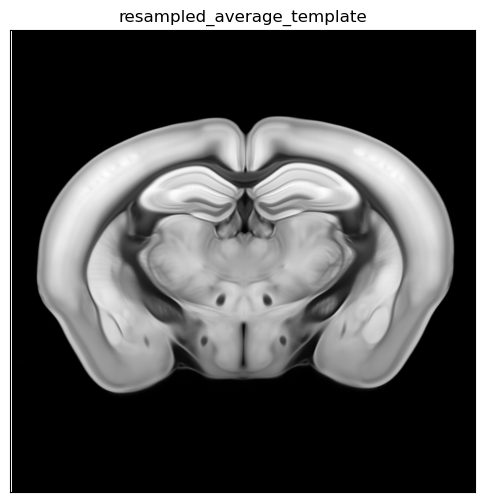

In [39]:
template_slice = average_template_array[zindex, :, :]
fig, ax = plot_section(overlay=template_slice, extent=extent)
res = ax.set_title('resampled_average_template')
plt.show()

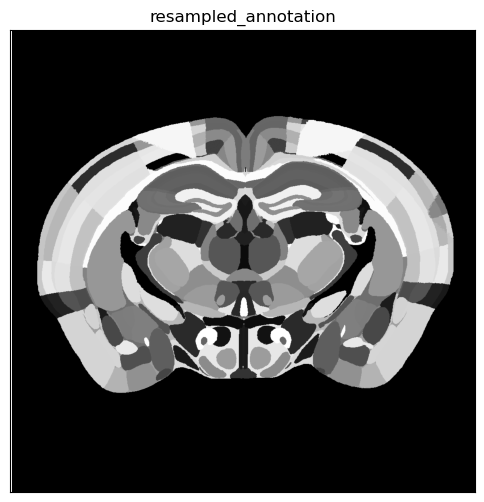

In [40]:
annotation_slice = annotation_array[zindex, :, :]
fig, ax = plot_section(overlay=annotation_slice, extent=extent)
res = ax.set_title('resampled_annotation')
plt.show()

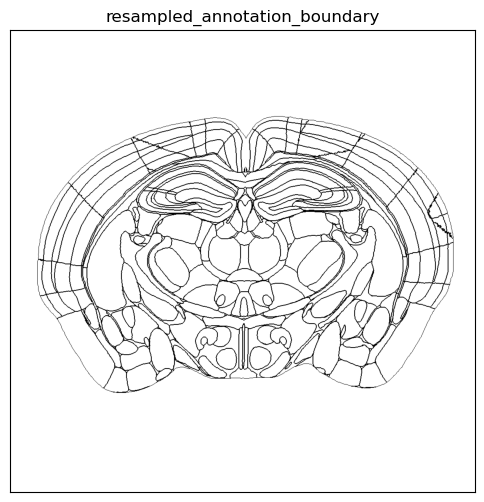

In [41]:
boundary_slice = annotation_boundary_array[zindex, :, :]
fig, ax = plot_section(overlay=boundary_slice, bcmap=plt.cm.Greys, extent=extent)
res = ax.set_title('resampled_annotation_boundary')
plt.show()

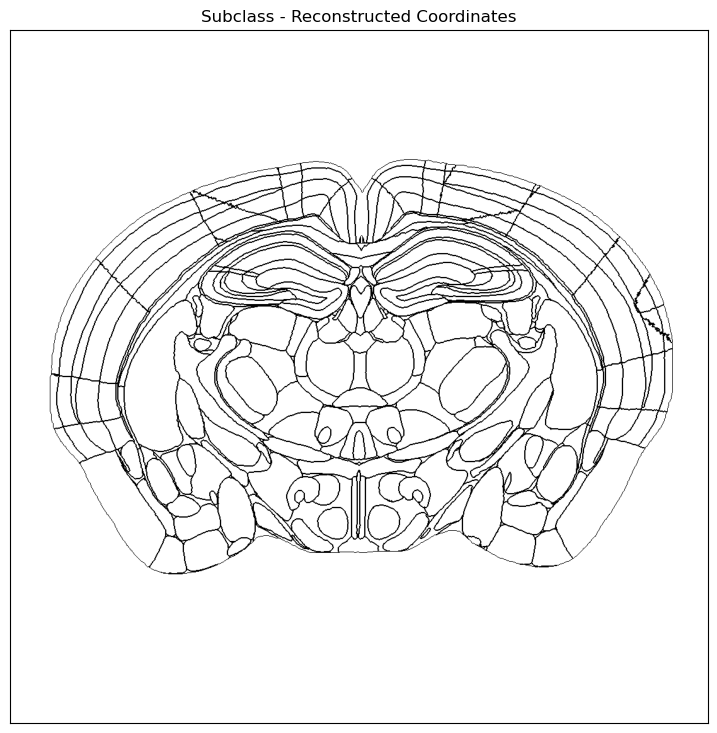

In [42]:
fig, ax = plot_section(section['x_reconstructed'],
                       section['y_reconstructed'], 
                       cc=section['subclass_color'],
                       overlay=boundary_slice,
                       extent=extent, 
                       bcmap=plt.cm.Greys,
                       alpha = 1.0*(boundary_slice>0),
                       fig_width = 9,
                       fig_height = 9 )
res = ax.set_title("Subclass - Reconstructed Coordinates")
plt.show()

In [11]:
cell_joined.columns

Index(['brain_section_label', 'cluster_alias', 'average_correlation_score',
       'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex',
       'x_section', 'y_section', 'z_section', 'neurotransmitter', 'class',
       'subclass', 'supertype', 'cluster', 'neurotransmitter_color',
       'class_color', 'subclass_color', 'supertype_color', 'cluster_color',
       'x_reconstructed', 'y_reconstructed', 'z_reconstructed',
       'parcellation_index', 'x_ccf', 'y_ccf', 'z_ccf', 'parcellation_organ',
       'parcellation_category', 'parcellation_division',
       'parcellation_structure', 'parcellation_substructure',
       'parcellation_organ_color', 'parcellation_category_color',
       'parcellation_division_color', 'parcellation_structure_color',
       'parcellation_substructure_color'],
      dtype='object')

In [12]:
# expr_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/C57BL6J-638850-raw.h5ad'
expr_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850-imputed/20240831/C57BL6J-638850-imputed-log2.h5ad'
expression_data = sc.read_h5ad(expr_path)
expression_data

AnnData object with n_obs × n_vars = 4334174 × 8460
    obs: 'brain_section_label'
    var: 'gene_symbol'

In [13]:
# Align metadata with expression data
common_cells = expression_data.obs_names.intersection(cell_joined.index)
expression_data = expression_data[common_cells, :]

# Add metadata to the AnnData object
expression_data.obs = cell_joined.loc[common_cells]
expression_data

AnnData object with n_obs × n_vars = 3739961 × 8460
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x_section', 'y_section', 'z_section', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'x_reconstructed', 'y_reconstructed', 'z_reconstructed', 'parcellation_index', 'x_ccf', 'y_ccf', 'z_ccf', 'parcellation_organ', 'parcellation_category', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure', 'parcellation_organ_color', 'parcellation_category_color', 'parcellation_division_color', 'parcellation_structure_color', 'parcellation_substructure_color'
    var: 'gene_symbol'

In [14]:
expression_data.obs.head()

,brain_section_label,cluster_alias,average_correlation_score,feature_matrix_label,donor_label,donor_genotype,donor_sex,x_section,y_section,z_section,...,parcellation_organ,parcellation_category,parcellation_division,parcellation_structure,parcellation_substructure,parcellation_organ_color,parcellation_category_color,parcellation_division_color,parcellation_structure_color,parcellation_substructure_color
cell_label,,,,,,,,,,,,,,,,,,,,,
1104095349100540743-1,C57BL6J-638850.52,128,0.601714,C57BL6J-638850,C57BL6J-638850,wt/wt,M,2.523144,5.745040,9.8,...,brain,grey,Isocortex,GU,GU6a,#FFFFFF,#BFDAE3,#70FF71,#009C75,#009C75
1018093345100600265,C57BL6J-638850.45,128,0.601081,C57BL6J-638850,C57BL6J-638850,wt/wt,M,1.934682,6.106153,8.2,...,brain,grey,Isocortex,SSs,SSs6a,#FFFFFF,#BFDAE3,#70FF71,#188064,#188064
1018135614102090183,C57BL6J-638850.55,128,0.524031,C57BL6J-638850,C57BL6J-638850,wt/wt,M,8.025767,5.027320,10.4,...,brain,grey,Isocortex,MOp,MOp6a,#FFFFFF,#BFDAE3,#70FF71,#1F9D5A,#1F9D5A
1104095348100570634,C57BL6J-638850.46,128,0.649367,C57BL6J-638850,C57BL6J-638850,wt/wt,M,8.999382,5.999297,8.4,...,brain,grey,CTXsp,CLA,CLA,#FFFFFF,#BFDAE3,#8ADA87,#8ADA87,#8ADA87
1018122109102452991,C57BL6J-638850.51,128,0.539654,C57BL6J-638850,C57BL6J-638850,wt/wt,M,8.487662,6.059709,9.6,...,brain,grey,CTXsp,CLA,CLA,#FFFFFF,#BFDAE3,#8ADA87,#8ADA87,#8ADA87


In [15]:
# Saving to file
# save_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/C57BL6J-638850-raw-wmeta-ccf.h5ad'
save_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850-imputed/20240831/C57BL6J-638850-imputed-log2-wmeta-ccf.h5ad'
expression_data.write_h5ad(save_path)

In [50]:
del expression_data